# Fourier Locking Paper — Figure Generation

Regenerates Figs. 1–5 of *Overcoming Fourier Locking in Quantum Data
Re-uploading Classifiers via Spectral Homotopy* from the experiment JSONs
produced by `FourierLocking_Experiments.ipynb`.

## Required data files (same directory)

| Figure | File | Experiment |
|---|---|---|
| Fig 1 | `experiment_a_results.json` | Diagnostic tracking (STD/ID, N=50) |
| Fig 2 | `experiment_b_results_clean.json` | Routing ablation (STD/ID/COUP, N=50) |
| Fig 3 | `experiment_f_bulletproof.json` | Curriculum ablation (N=50) |
| Fig 4 | `experiment_f_bulletproof.json` | FWD trajectories (`phase_accs`, `phase_xqfi`) |
| Fig 5 | — | Circuit diagram, drawn programmatically |

## Three Fisher quantities

Three distinct quantities appear in the data and are not interchangeable:

1. `fisher_traj` — classical Fisher discriminant ratio (FDR) of the measured
   features. Plotted in Fig. 1.
2. `qfim_traj` / `phase_qfi` — parameter-space QFIM scalar
   $\frac{1}{N}\mathrm{Tr}(F)$. Null diagnostic; not plotted.
3. `xqfi_traj` / `phase_xqfi` — input-space QFI $F_x$. Its trajectory is the
   mechanism signature; secondary axis of Fig. 4.

Each figure cell prints the statistics quoted in the corresponding results
section.

In [1]:
# Shared setup
import json
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pointbiserialr, fisher_exact

THRESHOLD = 0.65   # escape threshold used throughout the paper

plt.rcParams.update({
    'font.size': 10,
    'axes.titlesize': 11,
    'axes.labelsize': 11,
    'figure.dpi': 110,
})

def save(fig, name):
    fig.savefig(f'{name}.pdf', dpi=300, bbox_inches='tight')
    fig.savefig(f'{name}.png', dpi=200, bbox_inches='tight')
    print(f'Saved {name}.pdf / {name}.png')

## Figure 1 — FDR vs. final accuracy (STD condition)

Scatter of final test accuracy vs. the final Fisher discriminant ratio of the
measured features (`fisher_traj`) across the 50 STD seeds, with the
mean-prediction trap band, escape threshold, LOWESS trend, and point-biserial
correlation.

The cell also prints: the parameter-QFIM null; the input-QFI final-value null;
the $\Delta F_x$ migration signature; and the FDR early-warning correlations
at epochs 10 and 60.

N = 50, escapes = 4/50
FDR (fisher_traj)  final: r_pb = 0.9125, p = 2.93e-20   <- Fig 1 / Sec V.A
Param-QFIM (qfim_traj) final: r_pb = 0.0954, p = 0.51 (band 0.86-1.18)   <- null result
Input-QFI (xqfi_traj) final:  r_pb = -0.1903, p = 0.186   <- final value null
Delta F_x (E120-E0): escapees -30.5 (112 -> 82), trapped +1.0; r_pb = -0.476, p = 0.000475   <- spectral immobility/migration
FDR early warning E10: r_pb = 0.73
FDR early warning E60: r_pb = 0.90
Saved FIG_1.pdf / FIG_1.png


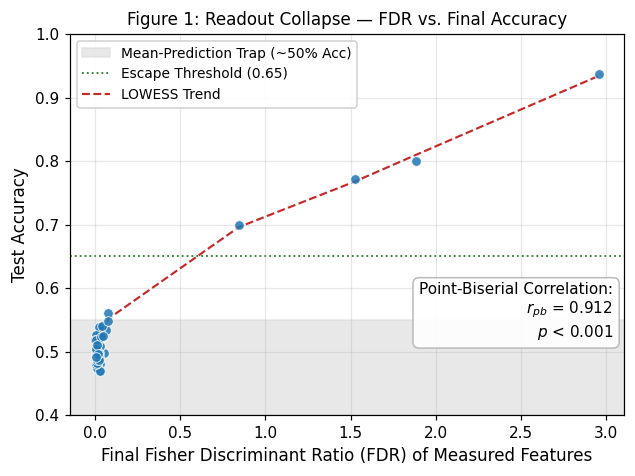

In [2]:
# --- Figure 1 ---
try:
    from statsmodels.nonparametric.smoothers_lowess import lowess
    HAVE_LOWESS = True
except ImportError:
    HAVE_LOWESS = False
    print('statsmodels not installed; LOWESS trend will be skipped')

with open('experiment_a_results.json') as f:
    data_a = json.load(f)

COND = 'std'   # paper Fig 1 uses the STD condition alone
accs = np.array(data_a[COND]['final_acc'])
n = len(accs)
fdrs  = np.array([data_a[COND]['fisher_traj'][str(i)][-1] for i in range(n)])
binary = (accs > THRESHOLD).astype(int)

r_pb, p_val = pointbiserialr(binary, fdrs)
print(f'N = {n}, escapes = {binary.sum()}/{n}')
print(f'FDR (fisher_traj)  final: r_pb = {r_pb:.4f}, p = {p_val:.3g}')

# --- Companion diagnostics ---
MILESTONES = [0, 10, 30, 60, 120]
if 'qfim_traj' in data_a[COND]:
    qfim = np.array([data_a[COND]['qfim_traj'][str(i)][-1] for i in range(n)])
    r_q, p_q = pointbiserialr(binary, qfim)
    print(f'Param-QFIM (qfim_traj) final: r_pb = {r_q:.4f}, p = {p_q:.3g} '
          f'(band {qfim.min():.2f}-{qfim.max():.2f})')
if 'xqfi_traj' in data_a[COND]:
    xq  = np.array([data_a[COND]['xqfi_traj'][str(i)] for i in range(n)])
    r_x, p_x = pointbiserialr(binary, xq[:, -1])
    print(f'Input-QFI (xqfi_traj) final:  r_pb = {r_x:.4f}, p = {p_x:.3g}')
    dx = xq[:, -1] - xq[:, 0]
    r_dx, p_dx = pointbiserialr(binary, dx)
    print(f'Delta F_x (E120-E0): escapees {dx[binary==1].mean():+.1f} '
          f'({xq[binary==1,0].mean():.0f} -> {xq[binary==1,-1].mean():.0f}), '
          f'trapped {dx[binary==0].mean():+.1f}; r_pb = {r_dx:.3f}, p = {p_dx:.3g}'
          f'')
for idx, ep in enumerate(MILESTONES[1:], start=1):
    f_ep = np.array([data_a[COND]['fisher_traj'][str(i)][idx] for i in range(n)])
    r_ep, _ = pointbiserialr(binary, f_ep)
    if ep in (10, 60):
        print(f'FDR early warning E{ep}: r_pb = {r_ep:.2f}')

# ---- Plot ----
fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.axhspan(0.40, 0.55, color='0.85', alpha=0.6, zorder=0,
           label='Mean-Prediction Trap (~50% Acc)')
ax.axhline(THRESHOLD, color='#2e7d32', linestyle=':', linewidth=1.2,
           zorder=1, label=f'Escape Threshold ({THRESHOLD})')
ax.scatter(fdrs, accs, s=40, color='#1f77b4', edgecolor='white',
           linewidth=0.6, zorder=3, alpha=0.85)
if HAVE_LOWESS:
    sm = lowess(accs, fdrs, frac=0.5, return_sorted=True)
    ax.plot(sm[:, 0], sm[:, 1], color='#c62828', linestyle='--',
            linewidth=1.4, zorder=2, label='LOWESS Trend')

ax.text(0.98, 0.35,
        f'Point-Biserial Correlation:\n$r_{{pb}}$ = {r_pb:.3f}\n$p$ < 0.001',
        transform=ax.transAxes, ha='right', va='top', fontsize=10,
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                  edgecolor='0.7', alpha=0.9))
ax.set_xlabel('Final Fisher Discriminant Ratio (FDR) of Measured Features')
ax.set_ylabel('Test Accuracy')
ax.set_title('Figure 1: Readout Collapse — FDR vs. Final Accuracy')
ax.set_ylim(0.40, 1.00)
ax.grid(True, alpha=0.3, zorder=0)
ax.legend(loc='upper left', fontsize=9, framealpha=0.9)
save(fig, 'FIG_1')
plt.show()


## Figure 2 — Routing ablation escape rates

Bar chart of escape rates for STD / ID / COUP. The p-value annotation reports the
worst (smallest) pairwise Fisher exact p against STD, demonstrating no significant
improvement from routing-side interventions.

STD  : 6/50 = 12%
ID   : 5/50 = 10%
COUP : 1/50 = 2%
ID vs STD: p = 1.000
COUP vs STD: p = 0.112
Saved FIG_2.pdf / FIG_2.png


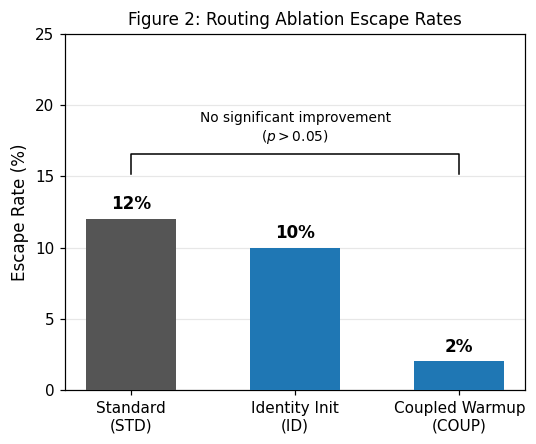

In [3]:
# --- Figure 2 ---
with open('experiment_b_results_clean.json') as f:
    data_b = json.load(f)

conds = ['std', 'id', 'coup']
labels = ['Standard\n(STD)', 'Identity Init\n(ID)', 'Coupled Warmup\n(COUP)']
colors = ['#555555', '#1f77b4', '#1f77b4']

rates, ns, escs = [], [], []
for c in conds:
    acc = np.array(data_b[c]['acc'] if 'acc' in data_b[c] else data_b[c]['final_acc'])
    esc = int((acc > THRESHOLD).sum())
    escs.append(esc); ns.append(len(acc)); rates.append(esc / len(acc) * 100)
    print(f'{c.upper():5s}: {esc}/{len(acc)} = {esc/len(acc)*100:.0f}%')

# Fisher exact vs STD for the interventions
p_min = 1.0
for i in (1, 2):
    tbl = [[escs[i], ns[i] - escs[i]], [escs[0], ns[0] - escs[0]]]
    _, p = fisher_exact(tbl)
    p_min = min(p_min, p)
    print(f'{conds[i].upper()} vs STD: p = {p:.3f}')

fig, ax = plt.subplots(figsize=(5.4, 4.2))
bars = ax.bar(labels, rates, color=colors, width=0.55, zorder=3)
for b, r in zip(bars, rates):
    ax.text(b.get_x() + b.get_width() / 2, r + 0.4, f'{r:.0f}%',
            ha='center', va='bottom', fontsize=11, weight='bold')

# Bracket annotation: no significant improvement
ymax = max(rates)
ax.annotate('No significant improvement\n($p > 0.05$)',
            xy=(1.0, ymax + 5.5), ha='center', fontsize=9)
ax.plot([0, 0, 2, 2], [ymax + 3.2, ymax + 4.6, ymax + 4.6, ymax + 3.2],
        color='black', lw=1.0, zorder=2)

ax.set_ylabel('Escape Rate (%)')
ax.set_title('Figure 2: Routing Ablation Escape Rates')
ax.set_ylim(0, max(25, ymax + 10))
ax.grid(True, axis='y', alpha=0.3, zorder=0)
save(fig, 'FIG_2')
plt.show()

## Figure 3 — Curriculum escape rates

Escape rates for the four matched-compute curricula (STD / FWD / RND / REV) from
`experiment_f_bulletproof.json`. Expected: 6% / 18% / 8% / 0% at N=50.

STD : 3/50 = 6%
FWD : 9/50 = 18%
RND : 4/50 = 8%
REV : 0/50 = 0%
FWD vs STD: one-sided p = 0.061, two-sided p = 0.121
RND vs STD: one-sided p = 0.500, two-sided p = 1.000
REV vs STD: one-sided p = 1.000, two-sided p = 0.242
Saved FIG_3.pdf / FIG_3.png


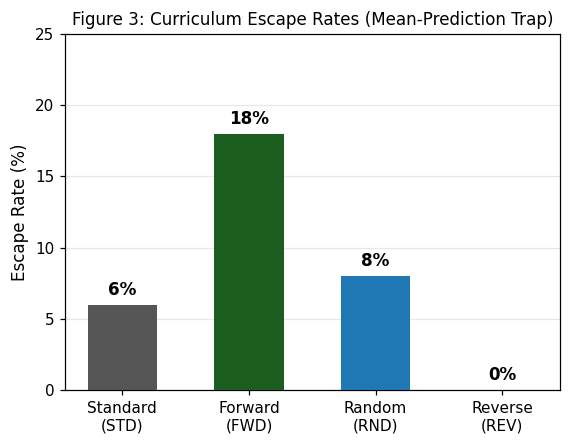

In [4]:
# --- Figure 3 ---
with open('experiment_f_bulletproof.json') as f:
    data_f = json.load(f)

conds = ['std', 'fwd', 'rnd', 'rev']
labels = ['Standard\n(STD)', 'Forward\n(FWD)', 'Random\n(RND)', 'Reverse\n(REV)']
colors = ['#555555', '#1b5e20', '#1f77b4', '#b71c1c']

rates = []
for c in conds:
    acc = np.array(data_f[c]['final_acc'])
    esc = int((acc > THRESHOLD).sum())
    rates.append(esc / len(acc) * 100)
    print(f'{c.upper():4s}: {esc}/{len(acc)} = {esc/len(acc)*100:.0f}%')

# Fisher exact tests vs STD (one-sided for the directional FWD hypothesis)
std_acc = np.array(data_f['std']['final_acc'])
std_esc = int((std_acc > THRESHOLD).sum())
for c in ['fwd', 'rnd', 'rev']:
    acc = np.array(data_f[c]['final_acc'])
    esc = int((acc > THRESHOLD).sum())
    tbl = [[esc, len(acc) - esc], [std_esc, len(std_acc) - std_esc]]
    _, p1 = fisher_exact(tbl, alternative='greater')
    _, p2 = fisher_exact(tbl)
    print(f'{c.upper()} vs STD: one-sided p = {p1:.3f}, two-sided p = {p2:.3f}')

fig, ax = plt.subplots(figsize=(5.8, 4.2))
bars = ax.bar(labels, rates, color=colors, width=0.55, zorder=3)
for b, r in zip(bars, rates):
    ax.text(b.get_x() + b.get_width() / 2, r + 0.4, f'{r:.0f}%',
            ha='center', va='bottom', fontsize=11, weight='bold')
ax.set_ylabel('Escape Rate (%)')
ax.set_title('Figure 3: Curriculum Escape Rates (Mean-Prediction Trap)')
ax.set_ylim(0, 25)
ax.grid(True, axis='y', alpha=0.3, zorder=0)
save(fig, 'FIG_3')
plt.show()

## Figure 4 — Accuracy and input-QFI $F_x$ trajectories (FWD)

Dual-axis plot: target-landscape accuracy (left) and mean input-QFI $F_x$
(right, `phase_xqfi`) across the three FWD phases, split by escape outcome.
Requires `phase_xqfi` in `experiment_f_bulletproof.json`.

Printed statistics: escapee $\Delta F_x = +24.4 \pm 25.6$, trapped
$+3.4 \pm 12.9$; $d = 1.34$, $r_{pb} = 0.46$, $p = 0.0007$; 8 of 9 escapees
rising; Phase-3 convergence $103.3$ vs $104.1$.

FWD escapees: 9/50
Escapee accuracy phase means: [0.501 0.496 0.829]
Trapped accuracy phase means: [0.502 0.499 0.505]
Delta F_x (P3-P1): escapees +24.4 +/- 25.6 (8/9 rising), trapped +3.4 +/- 12.9
Separation: d = 1.34, r_pb = 0.46, p = 0.0007
Phase-3 F_x convergence: escapees 103.3 vs trapped 104.1
Saved FIG_4.pdf / FIG_4.png


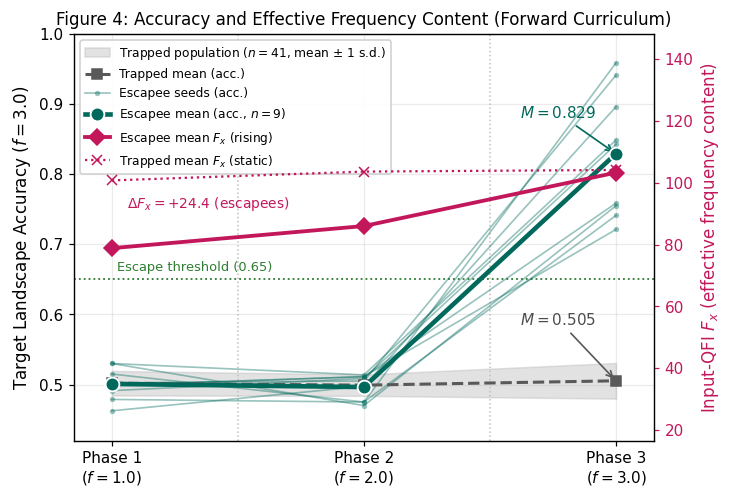

In [5]:
# --- Figure 4 ---
with open('experiment_f_bulletproof.json') as f:
    data_f = json.load(f)

fwd = data_f['fwd']
assert 'phase_xqfi' in fwd, (
    'experiment_f_bulletproof.json is missing phase_xqfi; re-run Experiment 3 '
    'with QFI logging and the reproduction gate merged in.')

accs_final = np.array(fwd['final_acc'])
n = len(accs_final)
escape_mask = accs_final > THRESHOLD

traj = np.array([fwd['phase_accs'][str(i)] for i in range(n)])
xqfi = np.array([fwd['phase_xqfi'][str(i)] for i in range(n)])
esc, trap = traj[escape_mask], traj[~escape_mask]
xq_e, xq_t = xqfi[escape_mask], xqfi[~escape_mask]
phases = np.array([1, 2, 3])

print(f'FWD escapees: {escape_mask.sum()}/{n}')
print(f'Escapee accuracy phase means: {esc.mean(axis=0).round(3)}')
print(f'Trapped accuracy phase means: {trap.mean(axis=0).round(3)}')

# --- Migration statistics ---
dx_e = xq_e[:, 2] - xq_e[:, 0]
dx_t = xq_t[:, 2] - xq_t[:, 0]
ne, nt = len(dx_e), len(dx_t)
sp = np.sqrt(((ne - 1) * dx_e.std(ddof=1)**2 + (nt - 1) * dx_t.std(ddof=1)**2)
             / (ne + nt - 2))
cohens_d = (dx_e.mean() - dx_t.mean()) / sp
dx_all = xqfi[:, 2] - xqfi[:, 0]
r_dx, p_dx = pointbiserialr(escape_mask.astype(int), dx_all)
print(f'Delta F_x (P3-P1): escapees {dx_e.mean():+.1f} +/- {dx_e.std(ddof=1):.1f} '
      f'({np.sum(dx_e > 0)}/{ne} rising), trapped {dx_t.mean():+.1f} +/- {dx_t.std(ddof=1):.1f}')
print(f'Separation: d = {cohens_d:.2f}, r_pb = {r_dx:.2f}, p = {p_dx:.4f}')
print(f'Phase-3 F_x convergence: escapees {xq_e[:,2].mean():.1f} vs trapped {xq_t[:,2].mean():.1f}')

# ---- Plot ----
fig, ax = plt.subplots(figsize=(6.8, 4.8))

# Trapped accuracy: shaded band (mean +/- 1 sd) + mean line
trap_mean, trap_sd = trap.mean(axis=0), trap.std(axis=0)
ax.fill_between(phases, trap_mean - trap_sd, trap_mean + trap_sd,
                color='0.75', alpha=0.45, zorder=1,
                label=f'Trapped population ($n={nt}$, mean $\\pm$ 1 s.d.)')
ax.plot(phases, trap_mean, color='0.35', lw=2.0, ls='--', marker='s',
        markersize=7, zorder=4, label='Trapped mean (acc.)')

# Individual escapee accuracy trajectories with vertex markers
for k, row in enumerate(esc):
    ax.plot(phases, row, color='#00695c', alpha=0.40, lw=1.1,
            marker='o', markersize=3.5, markerfacecolor='#00695c',
            markeredgecolor='none', zorder=3,
            label='Escapee seeds (acc.)' if k == 0 else None)

# Escapee accuracy mean: heavy line, large white-edged markers
esc_mean = esc.mean(axis=0)
ax.plot(phases, esc_mean, color='#00695c', lw=3.0, marker='o',
        markersize=9, markeredgecolor='white', markeredgewidth=1.2,
        zorder=5, label=f'Escapee mean (acc., $n={ne}$)')

# Endpoint annotations
ax.annotate(f'$M = {esc_mean[2]:.3f}$', xy=(3, esc_mean[2]),
            xytext=(2.62, 0.88), fontsize=10, color='#00695c',
            arrowprops=dict(arrowstyle='->', color='#00695c', lw=1.1))
ax.annotate(f'$M = {trap_mean[2]:.3f}$', xy=(3, trap_mean[2]),
            xytext=(2.62, 0.585), fontsize=10, color='0.30',
            arrowprops=dict(arrowstyle='->', color='0.35', lw=1.1))

# Escape threshold + phase boundaries
ax.axhline(THRESHOLD, color='#2e7d32', ls=':', lw=1.2, zorder=2)
ax.text(1.02, THRESHOLD + 0.008, 'Escape threshold (0.65)',
        fontsize=8.5, color='#2e7d32', va='bottom')
for x in (1.5, 2.5):
    ax.axvline(x, color='0.75', ls=':', lw=1.0, zorder=1)

# --- Secondary axis: input-QFI F_x ---
ax2 = ax.twinx()
ax2.plot(phases, xq_e.mean(axis=0), color='#c2185b', lw=2.5,
         marker='D', markersize=7, zorder=4,
         label='Escapee mean $F_x$ (rising)')
ax2.plot(phases, xq_t.mean(axis=0), color='#c2185b', lw=1.5,
         ls=':', marker='x', markersize=7, zorder=4,
         label='Trapped mean $F_x$ (static)')
ax2.annotate(f'$\\Delta F_x = {dx_e.mean():+.1f}$ (escapees)',
             xy=(1.5, (xq_e[:, 0].mean() + xq_e[:, 1].mean()) / 2),
             xytext=(1.06, xq_e[:, 0].mean() + 13), fontsize=9, color='#c2185b')
ax2.set_ylabel('Input-QFI $F_x$ (effective frequency content)', color='#c2185b')
ax2.tick_params(axis='y', colors='#c2185b')
pad = 0.12 * (xqfi.max() - xqfi.min())
ax2.set_ylim(xqfi[:, [0, 1, 2]].mean(axis=0).min() - 4 * pad,
             xqfi[:, [0, 1, 2]].mean(axis=0).max() + 2.2 * pad)

l1, lb1 = ax.get_legend_handles_labels()
l2, lb2 = ax2.get_legend_handles_labels()
ax.legend(l1 + l2, lb1 + lb2, loc='upper left', fontsize=8, framealpha=0.95)

ax.set_xticks(phases)
ax.set_xticklabels(['Phase 1\n($f=1.0$)', 'Phase 2\n($f=2.0$)', 'Phase 3\n($f=3.0$)'])
ax.set_xlim(0.85, 3.15)
ax.set_ylim(0.42, 1.0)
ax.set_ylabel('Target Landscape Accuracy ($f=3.0$)')
ax.grid(True, alpha=0.25, zorder=0)
ax.set_title('Figure 4: Accuracy and Effective Frequency Content (Forward Curriculum)')
save(fig, 'FIG_4')
plt.show()

## Figure 5 — DRU-PQC circuit diagram

Drawn programmatically. 4-qubit data-re-uploading circuit: encoding rotations
$R_X(\omega X + \omega')$; StronglyEntanglingLayers ($R_Z R_Y R_Z$) with a
CNOT ring (0→1, 1→2, 2→3, 3→0); one layer $l$ repeated $L=2$ times; all four
qubits measured; classical linear tail to logits.

Saved FIG_5.pdf / FIG_5.png


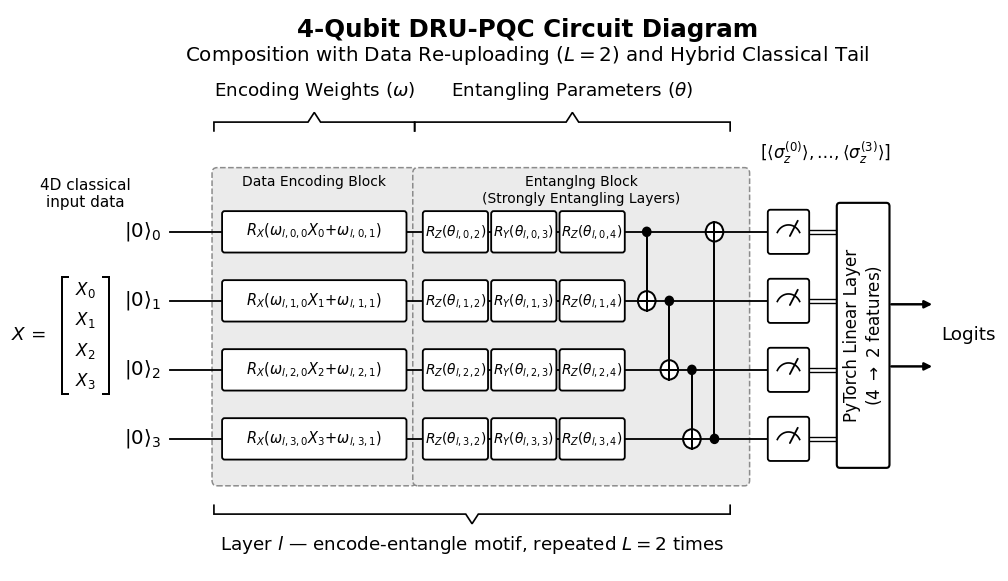

In [12]:
# --- Figure 5 ---
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.path import Path
import numpy as np

# ---------------- Layout constants ----------------
N_QUBITS = 4
WIRE_YS = [3.0, 2.0, 1.0, 0.0]          # y position per qubit (top to bottom)
WIRE_X0, WIRE_X1 = 0.0, 9.55            # wire extent

ENC_X, ENC_W = 0.85, 2.9                 # encoding block
ENT_X, ENT_W = 4.05, 4.3                 # entangling block (rotations + ring)
ROT_W, ROT_GAP = 1.0, 0.09             # rotation gate boxes
RING_X = 7.6                            # CNOT ring column start
METER_X = 9.55                          # measurement icons
LINEAR_X, LINEAR_W = 10.65, 0.8          # classical layer box

GATE_H = 0.56
FS_GATE = 9.5
FS_LABEL = 12
FS_TITLE = 16

fig, ax = plt.subplots(figsize=(11.0, 6.6))
ax.set_xlim(-1.75, 13.2)
ax.set_ylim(-1.9, 6.2)
ax.axis('off')


def gate_box(x, y, w, text, fs=FS_GATE):
    r = mpatches.FancyBboxPatch(
        (x, y - GATE_H / 2), w, GATE_H,
        boxstyle='round,pad=0.02,rounding_size=0.04',
        fc='white', ec='black', lw=1.2, zorder=3)
    ax.add_patch(r)
    ax.text(x + w / 2, y, text, ha='center', va='center',
            fontsize=fs, zorder=4)


def brace(x0, x1, y, label, above=True, fs=FS_LABEL):
    """Simple curly-brace-ish bracket drawn with a path."""
    h = 0.14 if above else -0.14
    mid = (x0 + x1) / 2
    verts = [(x0, y), (x0, y + h), (mid - 0.1, y + h), (mid, y + 2 * h),
             (mid + 0.1, y + h), (x1, y + h), (x1, y)]
    codes = [Path.MOVETO] + [Path.LINETO] * 6
    ax.add_patch(mpatches.PathPatch(Path(verts, codes), fc='none',
                                    ec='black', lw=1.1, zorder=3))
    ax.text(mid, y + 3.1 * h, label, ha='center',
            va='bottom' if above else 'top', fontsize=fs, zorder=4)


def meter(x, y):
    """Measurement icon."""
    r = mpatches.FancyBboxPatch(
        (x, y - 0.30), 0.62, 0.60,
        boxstyle='round,pad=0.02,rounding_size=0.04',
        fc='white', ec='black', lw=1.2, zorder=3)
    ax.add_patch(r)
    cx, cy = x + 0.31, y - 0.10
    th = np.linspace(np.pi * 0.15, np.pi * 0.85, 30)
    ax.plot(cx + 0.20 * np.cos(th), cy + 0.20 * np.sin(th),
            color='black', lw=1.1, zorder=4)
    ax.annotate('', xy=(cx + 0.17, cy + 0.30), xytext=(cx, cy),
                arrowprops=dict(arrowstyle='-', lw=1.2, color='black'),
                zorder=4)


# ---------------- Shaded block backgrounds ----------------
for (bx, bw, label, sub) in [
        (ENC_X - 0.15, ENC_W + 0.30, 'Data Encoding Block', None),
        (ENT_X - 0.15, (RING_X + 3 * 0.42 + 0.35) - ENT_X + 0.15,
         'Entangling Block', '(Strongly Entangling Layers)')]:
    bg = mpatches.FancyBboxPatch(
        (bx, -0.65), bw, 4.55,
        boxstyle='round,pad=0.03,rounding_size=0.08',
        fc='0.92', ec='0.55', lw=1.0, ls='--', zorder=1)
    ax.add_patch(bg)
    ax.text(bx + bw / 2, 3.62, label, ha='center', va='bottom',
            fontsize=(FS_LABEL + 1) * 0.7, zorder=4)
    if sub:
        ax.text(bx + bw / 2, 3.38, sub, ha='center', va='bottom',
                fontsize=(FS_LABEL + 1) * 0.7, zorder=4)


# ---------------- Wires and qubit labels ----------------
for q, y in enumerate(WIRE_YS):
    ax.plot([WIRE_X0, WIRE_X1], [y, y], color='black', lw=1.2, zorder=2)
    ax.text(WIRE_X0 - 0.15, y, rf'$|0\rangle_{q}$', ha='right',
            va='center', fontsize=FS_LABEL + 1, zorder=4)

# Classical input vector on the far left (mathtext can't do bmatrix;
# draw brackets manually with stacked entries)
vec_x, vec_yc = -1.35, 1.5
entries = [r'$X_0$', r'$X_1$', r'$X_2$', r'$X_3$']
for k, e in enumerate(entries):
    ax.text(vec_x, vec_yc + 0.66 - k * 0.44, e, ha='center',
            va='center', fontsize=FS_LABEL - 1, zorder=4)
# bracket strokes
for sgn in (-1, 1):
    bx = vec_x + sgn * 0.38
    ax.plot([bx, bx], [vec_yc - 0.85, vec_yc + 0.85], color='black',
            lw=1.3, zorder=4)
    ax.plot([bx, bx - sgn * 0.10], [vec_yc + 0.85, vec_yc + 0.85],
            color='black', lw=1.3, zorder=4)
    ax.plot([bx, bx - sgn * 0.10], [vec_yc - 0.85, vec_yc - 0.85],
            color='black', lw=1.3, zorder=4)
ax.text(vec_x - 0.62, vec_yc, r'$X\,=$', ha='right', va='center',
        fontsize=FS_LABEL, zorder=4)
ax.text(vec_x, 3.55, '4D classical\ninput data', ha='center',
        va='center', fontsize=FS_LABEL - 2, zorder=4)

# ---------------- Encoding gates ----------------
for q, y in enumerate(WIRE_YS):
    gate_box(ENC_X, y, ENC_W,
             rf'$R_X(\omega_{{l,{q},0}} X_{q} {{+}} \omega_{{l,{q},1}})$')

# ---------------- Entangling rotations ----------------
rot_names = ['Z', 'Y', 'Z']
for q, y in enumerate(WIRE_YS):
    for k in range(3):
        x = ENT_X + k * (ROT_W + ROT_GAP)
        gate_box(x, y, ROT_W,
                 rf'$R_{rot_names[k]}(\theta_{{l,{q},{k + 2}}})$',
                 fs=FS_GATE - 0.5)

# ---------------- CNOT ring: 0->1, 1->2, 2->3, 3->0 ----------------
def cnot(x, ctrl_y, targ_y):
    ax.plot([x, x], [ctrl_y, targ_y], color='black', lw=1.3, zorder=2)
    ax.add_patch(mpatches.Circle((x, ctrl_y), 0.065, fc='black',
                                 ec='black', zorder=4))
    ax.add_patch(mpatches.Circle((x, targ_y), 0.14, fc='white',
                                 ec='black', lw=1.3, zorder=3))
    ax.plot([x - 0.14, x + 0.14], [targ_y, targ_y], color='black',
            lw=1.3, zorder=4)
    ax.plot([x, x], [targ_y - 0.14, targ_y + 0.14], color='black',
            lw=1.3, zorder=4)

ring_dx = 0.36
cnot(RING_X + 0 * ring_dx, WIRE_YS[0], WIRE_YS[1])   # 0 -> 1
cnot(RING_X + 1 * ring_dx, WIRE_YS[1], WIRE_YS[2])   # 1 -> 2
cnot(RING_X + 2 * ring_dx, WIRE_YS[2], WIRE_YS[3])   # 2 -> 3
# closing CNOT 3 -> 0 (control bottom, target top)
cnot(RING_X + 3 * ring_dx, WIRE_YS[3], WIRE_YS[0])

# ---------------- Measurements ----------------
for q, y in enumerate(WIRE_YS):
    meter(METER_X, y)
ax.text(METER_X + 0.9, 3.95,
        r'$[\langle\sigma_z^{(0)}\rangle,\ldots,\langle\sigma_z^{(3)}\rangle]$',
        ha='center', va='bottom', fontsize=FS_LABEL - 1, zorder=4)

# Double classical wires from meters to linear layer
for q, y in enumerate(WIRE_YS):
    for dy in (-0.03, 0.03):
        ax.plot([METER_X + 0.62, LINEAR_X], [y + dy, y + dy],
                color='black', lw=0.9, zorder=2)

# ---------------- Classical linear layer ----------------
lin = mpatches.FancyBboxPatch(
    (LINEAR_X, -0.4), LINEAR_W, 3.8,
    boxstyle='round,pad=0.02,rounding_size=0.05',
    fc='white', ec='black', lw=1.4, zorder=3)
ax.add_patch(lin)
ax.text(LINEAR_X + LINEAR_W / 2, 1.5,
        'PyTorch Linear Layer\n' + r'(4 $\rightarrow$ 2 features)',
        ha='center', va='center', fontsize=FS_LABEL - 1,
        rotation=90, zorder=4)

# Logits arrows
for dy in (+0.45, -0.45):
    ax.annotate('', xy=(LINEAR_X + LINEAR_W + 0.75, 1.5 + dy),
                xytext=(LINEAR_X + LINEAR_W, 1.5 + dy),
                arrowprops=dict(arrowstyle='-|>', lw=1.6, color='black'),
                zorder=4)
ax.text(LINEAR_X + LINEAR_W + 0.85, 1.5, 'Logits', ha='left',
        va='center', fontsize=FS_LABEL, zorder=4)

# ---------------- Parameter braces (top) ----------------
brace(ENC_X - 0.15, ENC_X + ENC_W + 0.15, 4.45,
      r'Encoding Weights ($\omega$)')
brace(ENT_X - 0.15, RING_X + 3 * ring_dx + 0.25, 4.45,
      r'Entangling Parameters ($\theta$)')

# ---------------- Layer brace (bottom, corrected) ----------------
brace(ENC_X - 0.15, RING_X + 3 * ring_dx + 0.25, -0.95,
      r'Layer $l$ — encode-entangle motif, repeated $L=2$ times',
      above=False)

# ---------------- Title ----------------
ax.text(5.7, 6.1, '4-Qubit DRU-PQC Circuit Diagram',
        ha='center', va='top', fontsize=FS_TITLE, weight='bold')
ax.text(5.7, 5.72,
        r'Composition with Data Re-uploading ($L=2$) and Hybrid Classical Tail',
        ha='center', va='top', fontsize=FS_TITLE - 3)

save(fig, 'FIG_5')
plt.show()